In [1]:
%pwd

'C:\\Users\\Mohit Kedia\\Notebooks\\Refactored_Py_DS_ML_Bootcamp-master\\11-Linear-Regression'

In [ ]:
1. #Load the data

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
df=pd.read_csv("ecommerce_data.csv")

In [ ]:
2. # Reading the file

In [9]:
df.head()

,\tEmail,Address,Avatar,Time on App,Time on Website,Price,Discount,Marketing spend,Rating,Sales,Date
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,12.66,39.58,632,9,6389,5,623,01-01-2024
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,11.11,37.27,575,9,6252,4,566,02-01-2024
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,11.33,37.11,282,15,3341,3,267,03-01-2024
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,13.72,36.72,264,17,3962,5,247,04-01-2024
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,12.80,37.54,254,8,9230,4,246,05-01-2024


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   	Email           500 non-null    object 
 1   Address          500 non-null    object 
 2   Avatar           500 non-null    object 
 3   Time on App      500 non-null    float64
 4   Time on Website  500 non-null    float64
 5   Price            500 non-null    int64  
 6   Discount         500 non-null    int64  
 7   Marketing spend  500 non-null    int64  
 8   Rating           500 non-null    int64  
 9   Sales            500 non-null    int64  
 10  Date             500 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 43.1+ KB


In [11]:
df.describe()

,Time on App,Time on Website,Price,Discount,Marketing spend,Rating,Sales
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,12.052620,37.060480,564.604000,12.286000,5490.426000,3.986000,552.318000
std,0.994418,1.010555,260.758342,4.508309,2557.044435,0.850441,260.907091
min,8.510000,33.910000,102.000000,5.000000,1000.000000,3.000000,85.000000
25%,11.390000,36.347500,342.000000,9.000000,3333.250000,3.000000,327.750000
50%,11.980000,37.070000,569.500000,12.000000,5528.500000,4.000000,554.500000
75%,12.752500,37.720000,783.000000,16.000000,7703.250000,5.000000,767.500000
max,15.130000,40.010000,999.000000,20.000000,9987.000000,5.000000,988.000000


In [15]:
3. # Exploratory Data Analysis

C:\Users\Mohit Kedia\AppData\Local\Temp\ipykernel_14956\4256165467.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Sales'])


<Axes: xlabel='Sales', ylabel='Density'>

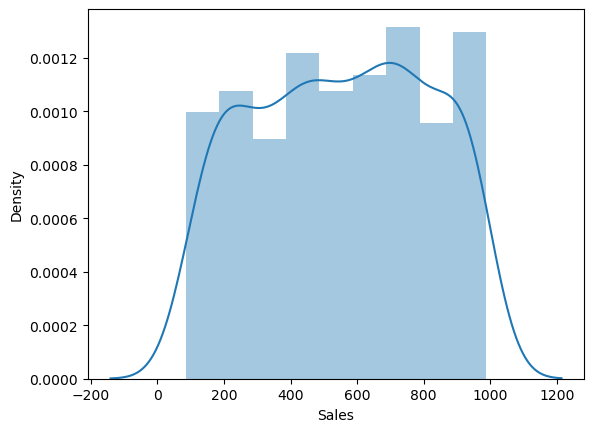

In [17]:
sns.distplot(df['Sales'])

C:\Users\Mohit Kedia\AppData\Local\Temp\ipykernel_14956\4285799579.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Sales'],kde=False,bins=30)


<Axes: xlabel='Sales'>

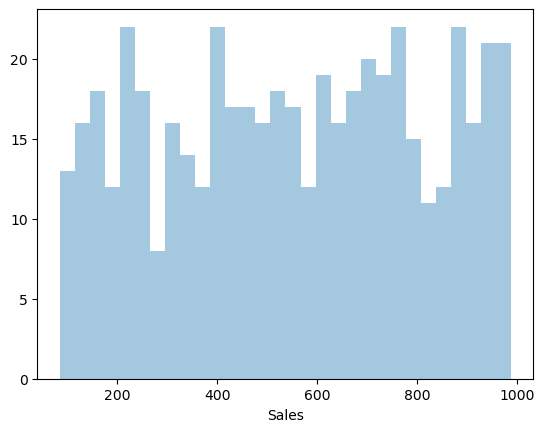

In [19]:
sns.distplot(df['Sales'],kde=False,bins=30)

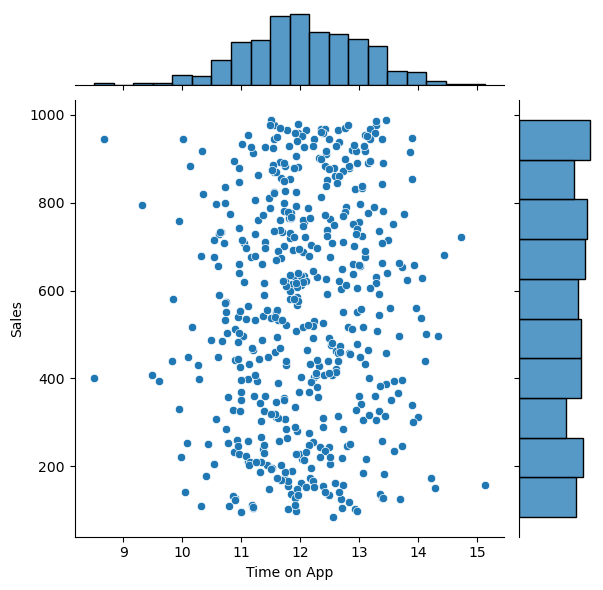

In [22]:
sns.jointplot(x='Time on App', y='Sales', data = df, kind='scatter')

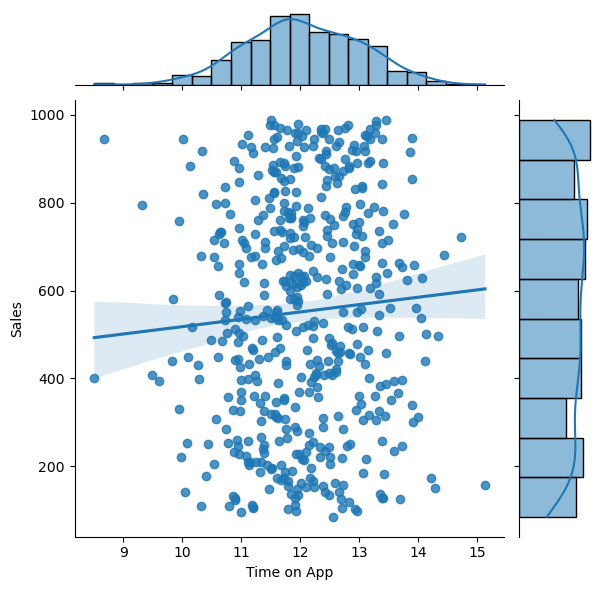

In [23]:
sns.jointplot(x='Time on App', y='Sales', data=df, kind='reg')

C:\Users\Mohit Kedia\AppData\Local\Temp\ipykernel_14956\954606326.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm')


<Axes: >

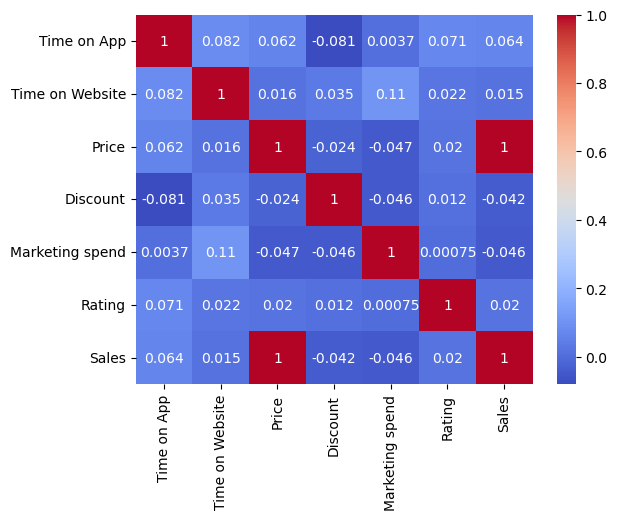

In [24]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='Marketing spend', ylabel='Sales'>

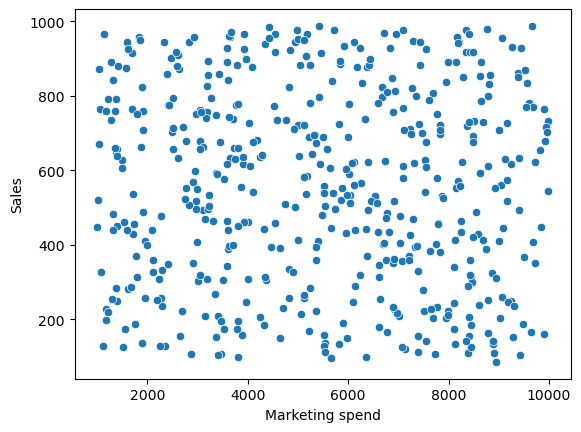

In [27]:
sns.scatterplot(x='Marketing spend',y='Sales', data = df)

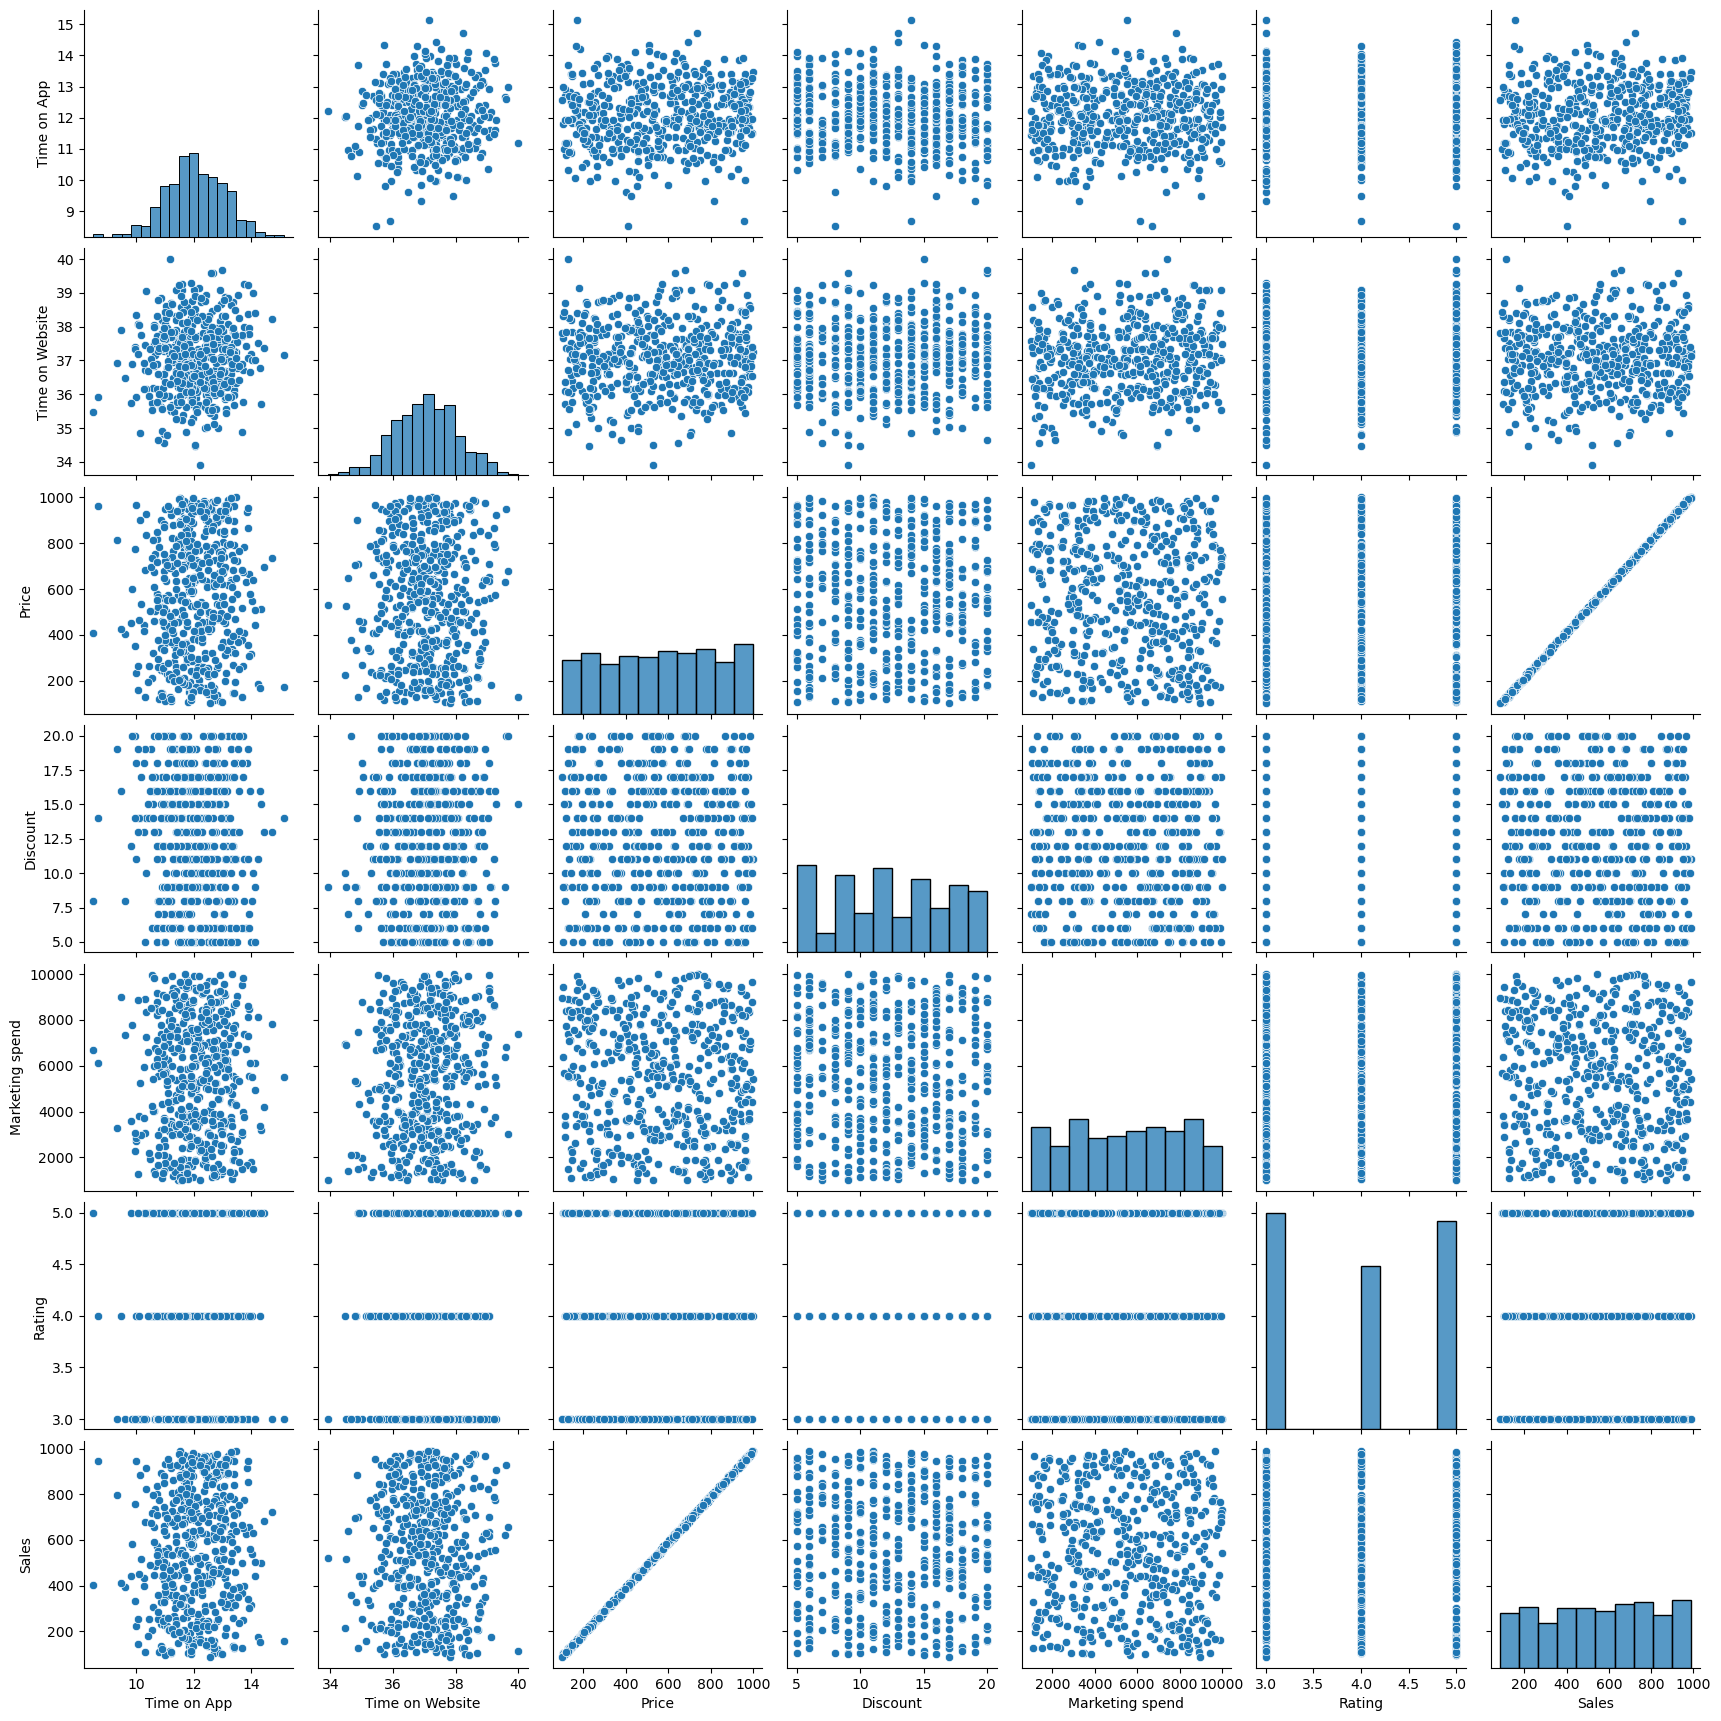

In [32]:
sns.pairplot(df)

In [25]:
4. # Data preprocessing via Check missing values

In [26]:
print(df.isnull().sum())

\tEmail            0
Address            0
Avatar             0
Time on App        0
Time on Website    0
Price              0
Discount           0
Marketing spend    0
Rating             0
Sales              0
Date               0
dtype: int64


In [36]:
5. # Features and target
X=df[['Price','Discount','Time on App','Time on Website','Marketing spend','Rating']]
y=df['Sales']

In [ ]:
6. # Train Test Split

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [39]:
7.# Model

In [40]:
from sklearn.linear_model import LinearRegression

In [55]:
lm = LinearRegression()

In [56]:
lm.fit(X_train,y_train)

LinearRegression()

In [44]:
# The coefficients
print('Coefficients: \n', lm.coef_)

Coefficients: 
 [ 1.00000000e+00 -1.00000000e+00  3.66673350e-15 -3.96469852e-14
  1.49081155e-16 -5.42157854e-15]


In [43]:
8. #Predictions

In [45]:
predictions = lm.predict( X_test)

Text(0, 0.5, 'Predicted Y')

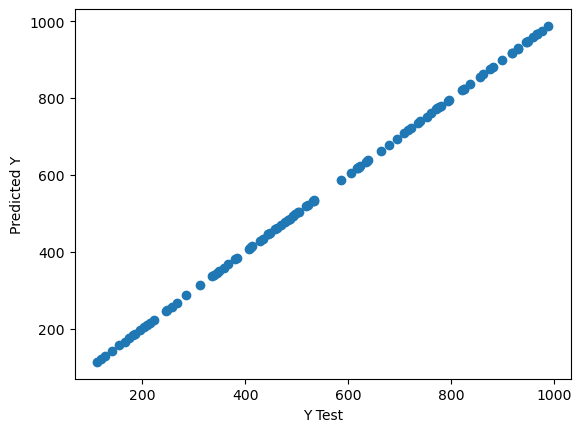

In [58]:
plt.scatter(y_test,predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

In [ ]:
# Evaluating the model

In [59]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 3.2343905331799763e-13
MSE: 1.5041116216540405e-25
RMSE: 3.8782877944449154e-13


In [ ]:
# Residuals

C:\Users\Mohit Kedia\AppData\Local\Temp\ipykernel_14956\1326397652.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test-predictions),bins=50);


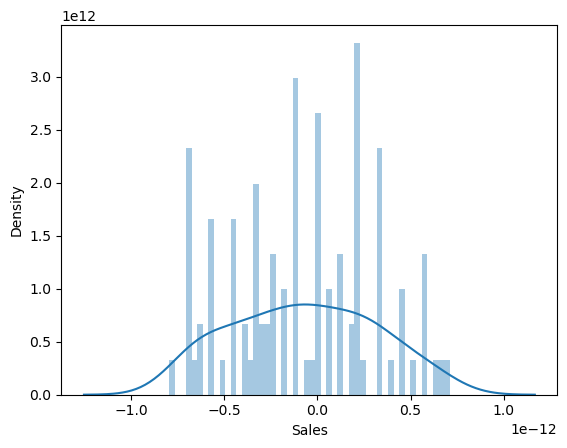

In [60]:
sns.distplot((y_test-predictions),bins=50);

In [50]:
coeffecients = pd.DataFrame(lm.coef_,X.columns)
coeffecients.columns = ['Coeffecient']
coeffecients

,Coeffecient
Price,1.000000e+00
Discount,-1.000000e+00
Time on App,3.666733e-15
Time on Website,-3.964699e-14
Marketing spend,1.490812e-16
Rating,-5.421579e-15


In [ ]:
#Based on Coeffecients values for different x variables, Sales can be calculated or predicted.